# Exercise 2

In [8]:
%pip install --user tensorflow
%pip install --user autograd
%pip install --user pandas
%pip install --user  matplotlib
%pip install --user  scipy
%pip install --user  MLRPlotting
%pip install --user  numba


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement MLRPlotting (from versions: none)
ERROR: No matching distribution found for MLRPlotting


Note: you may need to restart the kernel to use updated packages.


In [9]:
#%pip install ipykernel
#python -m ipykernel install --user --name=my_env --display-name "Python (my_env)"


In [10]:
!where python
import os
os.environ["PATH"] += ";C:\\Users\\Whatever\\AppData\\Roaming\\Python\\Python311\\Scripts"
print(os.environ["PATH"])

C:\Users\Whatever\anaconda3\python.exe
C:\Users\Whatever\AppData\Local\Microsoft\WindowsApps\python.exe
C:\Users\Whatever\anaconda3;C:\Users\Whatever\anaconda3\Library\mingw-w64\bin;C:\Users\Whatever\anaconda3\Library\usr\bin;C:\Users\Whatever\anaconda3\Library\bin;C:\Users\Whatever\anaconda3\Scripts;C:\WINDOWS\system32;C:\WINDOWS;C:\WINDOWS\System32\Wbem;C:\WINDOWS\System32\WindowsPowerShell\v1.0\;C:\WINDOWS\System32\OpenSSH\;C:\Program Files\MATLAB\R2023b\bin;C:\Program Files\Wolfram Research\WolframScript\;C:\Users\Whatever\AppData\Local\Microsoft\WindowsApps;C:\Users\Whatever\AppData\Local\Programs\MiKTeX\miktex\bin\x64\;;C:\Users\Whatever\AppData\Roaming\Python\Python311\Scripts;C:\Users\Whatever\AppData\Roaming\Python\Python311\Scripts;C:\Users\Whatever\AppData\Roaming\Python\Python311\Scripts


In [11]:
#import sys
#print(sys.version)
#!pip show tensorflow


In [13]:
import tensorflow as tf
from autograd import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
from autograd.misc.flatten import flatten_func
from autograd import grad,jacobian
from autograd import value_and_grad, hessian
from autograd.scipy.special import logsumexp
from MLRPlotting import static_plotter
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

ModuleNotFoundError: No module named 'MLRPlotting'

In [ ]:
static_plotter = static_plotter.Visualizer();
cost_1 = [1,2,7,9]
cost_2 = [9,6,3,1]
# plot the cost function history for two runs
static_plotter.plot_cost_histories([cost_1,cost_2],start=0,points=True,labels=[r'Test_1',r'Test_2'])

In [ ]:
import sys
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_labels.shape=(1,60000)
test_labels.shape=(1,10000)
train_images=(train_images.reshape(60000,784)).T
test_images=(test_images.reshape(10000,784)).T

train_labels=np.array([train_labels[0][:600]])
train_images=np.array(train_images[:,:600])

print(train_images.shape)
print(test_images.shape)
print(train_labels.shape)
print(test_labels.shape)
print(train_images.dtype)
np.set_printoptions(threshold=sys.maxsize)
#print(train_labels)
print(train_labels.dtype)

In [ ]:
from autograd.scipy.special import logsumexp
# compute C linear combinations of input point, one per classifier
def model(x,w):
    a = w[0] + np.dot(x.T,w[1:])
    return a.T

# multiclass perceptron
def multiclass_perceptron(w,x,y,iter):
# get subset of points
    #print(x.shape,y.shape)
    x_p = x[:,iter]
    y_p = y[:,iter]
    # pre-compute predictions on all points
    all_evals = model(x_p,w)
    # compute maximum across data points
    a = logsumexp(all_evals, axis=0) 
    #a = max(all_evals, axis=0) 
    # compute cost in compact form using numpy broadcasting
    b = all_evals[y_p.astype(int).flatten(),np.arange(np.size(y_p))]
    cost = np.sum(a - b)
    # return average
    return cost/float(np.size(y_p))

In [ ]:
#from numba import jit


def gradient_descent(g1, w, x_train, y_train, alpha, max_its, batch_size):
 # compute gradient module using autograd
    num_train=x_train.shape[1]
    g, unflatten, w = flatten_func(g1,w)
    print(y_train.shape[1])
    gradient = jacobian(lambda w: g(w, x_train, y_train, np.array(range(y_train.shape[1]))))
    print('!!!!!!')
    num_batches = int(np.ceil(np.divide(num_train, batch_size)))
    #print(num_train, batch_size)
    
     # run the gradient descent loop
    weight_history = [] # container for weight history
    cost_history = [] # container for corresponding cost function history
    d=-gradient(w)[1]
    beta=0.5
    for i in range(max_its):
        for k in range(num_batches):
            
         # evaluate the gradient, store current weights and cost function value
            b=k
            batch_inds = np.arange(b*batch_size, min((b+1)*batch_size, num_train))
            print(b*batch_size, min((b+1)*batch_size, num_train))
            cost_eval,grad_eval = gradient(w)
             # take gradient descent step
            d=beta*d+(1-beta)*(-grad_eval)
            w = w + alpha*d
             # record weight and cost
            weight_history.append(w)
            cost_history.append(g1(w, x_train, y_train,batch_inds))
    return weight_history,cost_history



In [4]:


# Convert data to float64
train_images = train_images.astype(np.float64)
train_labels = train_labels.astype(np.float64)

# Initialize weights
N, C = train_images.shape[0], 10  # 10 classes
w_init = 0.1 * np.random.randn(N+1, C)  # (N+1) for bias term
print('300 batches is needed for a full ephoch when batch_size=200')
# Train using mini-batch (batch_size=200)
w_mini, cost_mini = gradient_descent(multiclass_perceptron, w_init, train_images, train_labels, alpha=0.001, max_its=5, batch_size=200)
print('1 batches is needed for a full ephoch when batch_size=60000')
# Train using full-batch
w_full, cost_full = gradient_descent(multiclass_perceptron, w_init, train_images, train_labels, alpha=0.001, max_its=5, batch_size=train_images.shape[1])

# Plot cost history
pstatic_plotter.plot_cost_histories([cost_mini,cost_full],start=0,points=False,labels=[r'batch_size=200',r'full batch'])

NameError: name 'train_images' is not defined

# Exercise 3

# Exercise 4

# Exercise 5

In [107]:
def update_assignments(data,centroids):
    P = np.shape(data)[1]
    assignments = []
    for p in range(P):
        x_p = data[:,p][:,np.newaxis]
        diffs = np.sum((x_p - centroids)**2,axis = 0)
        # determine closest centroid
        ind = np.argmin(diffs)
        assignments.append(ind)
    return np.array(assignments)
       
def update_centroids(data,old_centroids,assignments):
    K = old_centroids.shape[1]

    centroids = []
    for k in range(K):
        S_k = np.argwhere(assignments == k)
        c_k = 0
        if np.size(S_k) > 0:
            c_k = np.mean(data[:,S_k],axis = 1)
            
        else:
            centroids[:, k] = data[:, np.random.choice(data.shape[1])]
        centroids.append(c_k)
    centroids = np.array(centroids)[:,:,0]
    return centroids.T

# main k-means function
def my_kmeans(data,centroids,max_its):    
    for j in range(max_its):
        
        assignments = update_assignments(data,centroids)
        centroids = update_centroids(data,centroids,assignments)
        centroids_p=centroids
        
    # final assignment update
    assignments = update_assignments(data,centroids)
    plt.scatter(data[0,:],data[1,:],c = 'k',alpha=0.5)
    plt.scatter(centroids_p[0],centroids_p[1],c='r',marker='*' ,s=300)
    plt.show()
    return centroids,assignments

(2, 50)


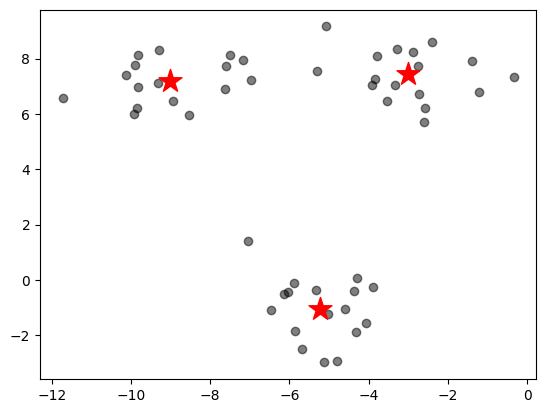

In [110]:
data = np.loadtxt(r"C:\Users\Whatever\Desktop\blobs.dat")
print(data.shape)
r = np.arange(np.shape(data)[1])
for k in [2]:
    num_clusters=k+1
    pts = np.random.permutation(r)[:num_clusters]
    iniit_centroids = data[:,pts]
    
    #print(iniit_centroids)
    max_its = 5

    centroids,assignments = my_kmeans(data,iniit_centroids,max_its)




 k = 1


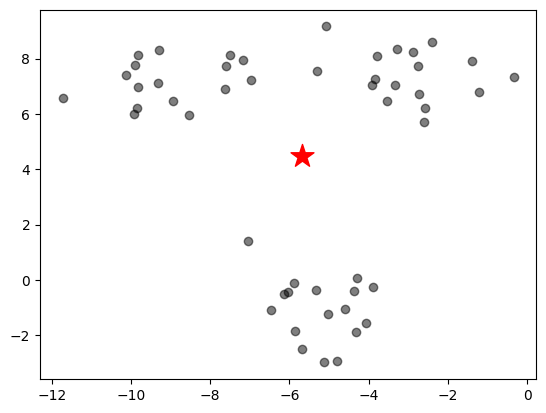




 k = 2


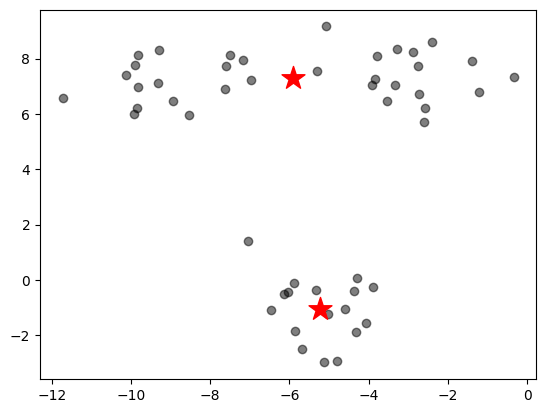




 k = 3


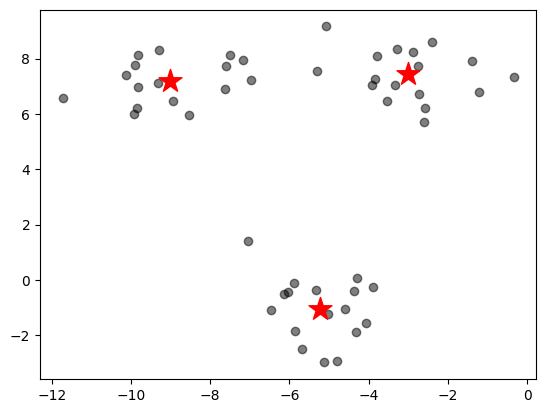




 k = 4


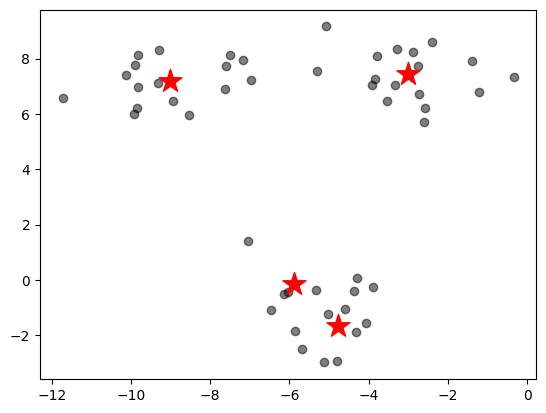




 k = 5


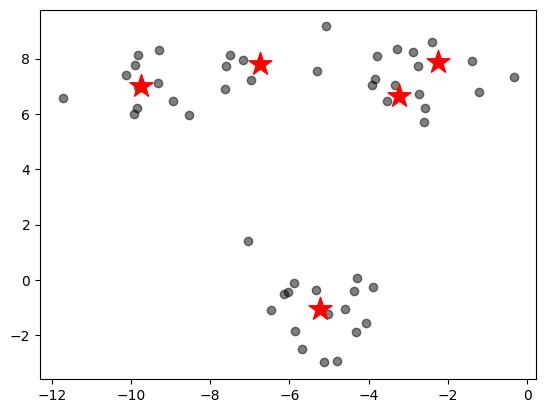




 k = 6


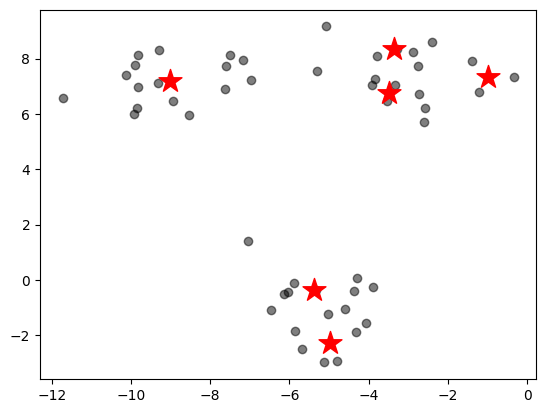




 k = 7


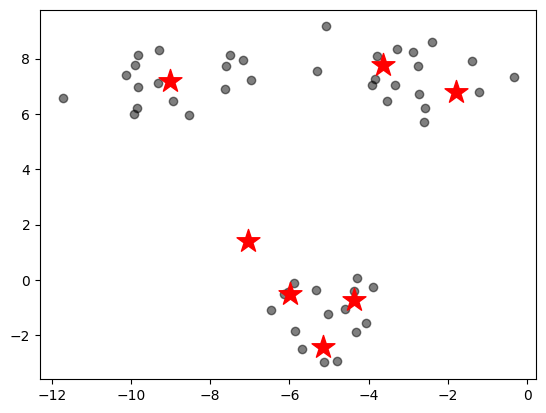




 k = 8


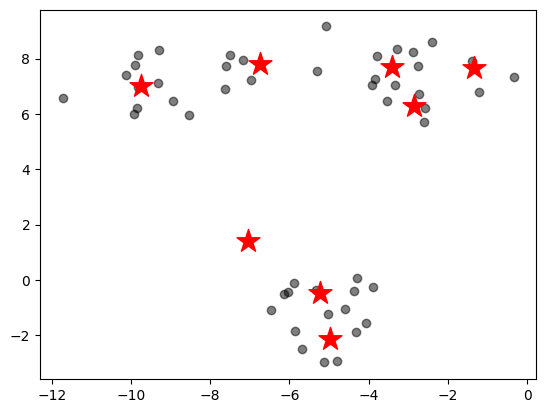




 k = 9


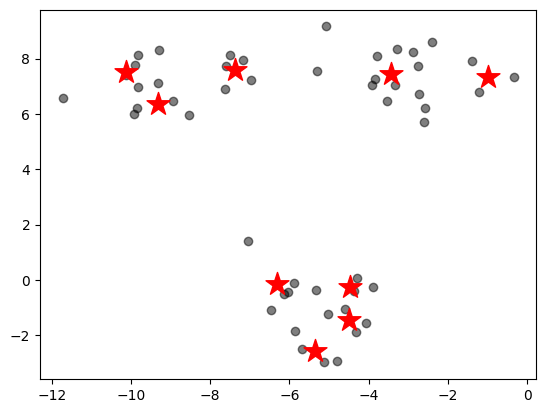




 k = 10


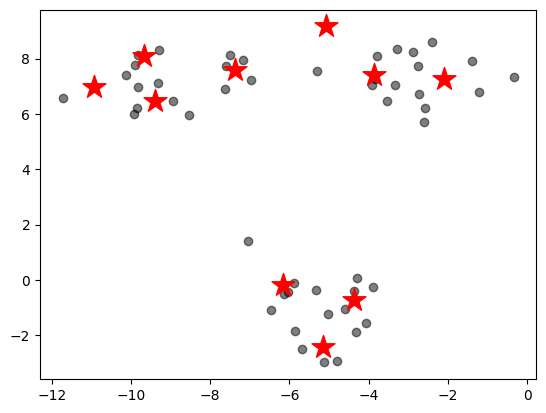

In [115]:
data = np.loadtxt(r"C:\Users\Whatever\Desktop\blobs.dat")
#print(data.shape)
r = np.arange(np.shape(data)[1])
for k in range(10):
    num_clusters=k+1
    print('\n\n\n k =',num_clusters)
    pts = np.random.permutation(r)[:num_clusters]
    iniit_centroids = data[:,pts]
    
    #print(iniit_centroids)
    max_its = 5

    centroids,assignments = my_kmeans(data,iniit_centroids,max_its)

It shows that this program can't give a clear indication of the correct value for K.

# Exercise 6

In [116]:
import numpy as np
from urllib.request import urlopen
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt'
raw_data = urlopen(url)
dataset = np.loadtxt(raw_data, delimiter=",")
print(dataset.shape)

(1372, 5)


In [143]:
X=dataset[:,[1,3]]
Y=dataset[:,4]
print(X.shape)
print(Y.shape)

(1372, 2)
(1372,)


In [150]:
a=np.array([1,2,3,-2,-3,1,2])
np.sign([1,2,3,-2,-3])
np.where(a>0)

(array([0, 1, 2, 5, 6]),)

## 6.1.

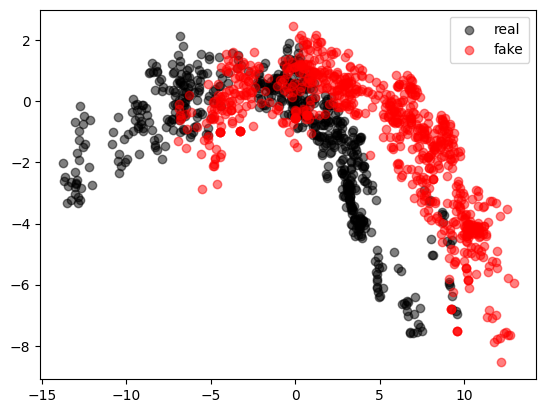

In [153]:
def real_or_fake(x1,y1):
    y2=y1-0.5
    real=x1[np.where(y2>0)]
    fake=x1[np.where(y2<0)]
    return real,fake
real,fake=real_or_fake(X,Y)
RT=np.array(real).T
FT=np.array(fake).T

#print(RT.shape)
plt.scatter(RT[0],RT[1],c = 'k',alpha=0.5)
plt.scatter(FT[0],FT[1],c = 'r',alpha=0.5)

plt.legend( labels=['real', 'fake'])

There is a visual separation line at larger x1,but at smaller x1 they are mixed.
## 6.2.

(1372, 2)
(1372,)
Epoch 1/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6332 - loss: 0.6234  
Epoch 2/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7483 - loss: 0.4622 
Epoch 3/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7490 - loss: 0.4463 
Epoch 4/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7602 - loss: 0.4242 
Epoch 5/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7797 - loss: 0.4124 
Epoch 6/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7825 - loss: 0.4062 
Epoch 7/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7973 - loss: 0.3801 
Epoch 8/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7854 - loss: 0.3990  
Epoch 9/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7997 - loss: 0.3971 
Epoch 10/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7944 - loss: 0.3854 
Epoch 11/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7995 - loss: 0.3867 
Epoch 12/400
11/11 ━━━━━━━━━━━━━

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8610 - loss: 0.3252 
Epoch 136/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8697 - loss: 0.2901 
Epoch 137/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8725 - loss: 0.2807 
Epoch 138/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8662 - loss: 0.2829
Epoch 139/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8760 - loss: 0.2592 
Epoch 140/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8810 - loss: 0.2881 
Epoch 141/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8525 - loss: 0.2924  
Epoch 142/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8725 - loss: 0.2879 
Epoch 143/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8773 - loss: 0.2884
Epoch 144/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8733 - loss: 0.2808 
Epoch 145/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8573 - loss: 0.2830
Epoch 146/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8706 - loss: 0.2766  
Epoch 203/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8674 - loss: 0.2641 
Epoch 204/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8710 - loss: 0.2721 
Epoch 205/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8671 - loss: 0.2874 
Epoch 206/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8700 - loss: 0.2778  
Epoch 207/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8732 - loss: 0.2765 
Epoch 208/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8918 - loss: 0.2612 
Epoch 209/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8765 - loss: 0.2761 
Epoch 210/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8708 - loss: 0.2786  
Epoch 211/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8722 - loss: 0.2827 
Epoch 212/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8661 - loss: 0.2867 
Epoch 213/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8817 - loss: 0.2588  
Epoch 270/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8718 - loss: 0.2776  
Epoch 271/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8752 - loss: 0.2672 
Epoch 272/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8725 - loss: 0.2980  
Epoch 273/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8848 - loss: 0.2522 
Epoch 274/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8830 - loss: 0.2803  
Epoch 275/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8843 - loss: 0.2644 
Epoch 276/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8905 - loss: 0.2595  
Epoch 277/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8873 - loss: 0.2626
Epoch 278/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8434 - loss: 0.3817 
Epoch 279/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8627 - loss: 0.2884 
Epoch 280/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8762 - loss: 0.2683 
Epoch 337/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8580 - loss: 0.3005
Epoch 338/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8879 - loss: 0.2646 
Epoch 339/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8793 - loss: 0.2650
Epoch 340/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8600 - loss: 0.3365 
Epoch 341/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8682 - loss: 0.2785 
Epoch 342/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8831 - loss: 0.2775  
Epoch 343/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8725 - loss: 0.2765 
Epoch 344/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8779 - loss: 0.2766
Epoch 345/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8699 - loss: 0.2889  
Epoch 346/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8846 - loss: 0.2773
Epoch 347/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 

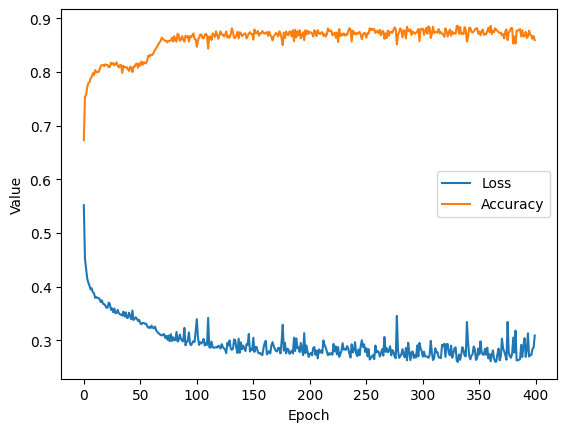

In [198]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
X=dataset[:,[1,3]]
Y=dataset[:,4]
print(X.shape)
print(Y.shape)
#X = X.reshape((X.shape[0], 1, X.shape[1]))  # Reshapes the input to (batch_size, timesteps, features)

'''model = Sequential([
    Dense(1, input_shape=(None, 2), activation='sigmoid')
])'''
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(2,)),  
    tf.keras.layers.Dense(1, activation='sigmoid')  
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.15),
              loss='binary_crossentropy',
              metrics=['accuracy'])


history = model.fit(X, Y, epochs=400, batch_size=128, verbose=1)

plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['accuracy'], label='Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.show()

The logistic regression is working well
## 6.3.

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


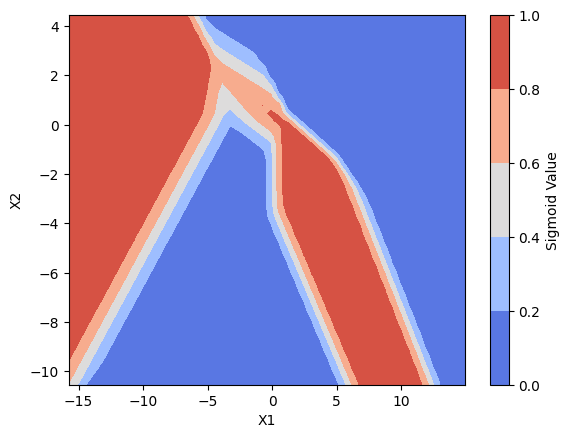

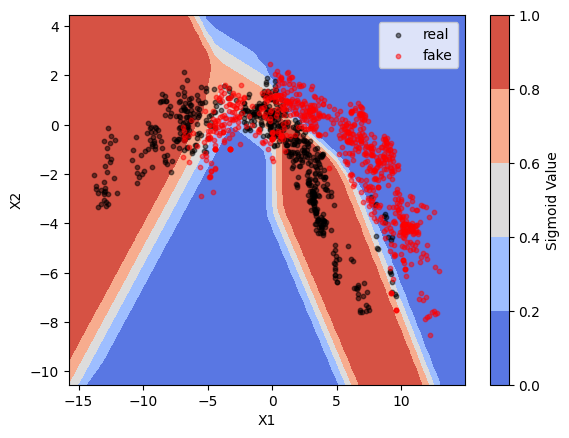

In [199]:
'''def sigmoid_2d(x, y):
    return 1 / (1 + np.exp(-(x + y)))'''
x1list = np.linspace(np.min(X[:,0])-2, np.max(X[:,0])+2, 50) # Define 50 points on the x1-axis
x2list = np.linspace(np.min(X[:,1])-2, np.max(X[:,1])+2, 50) # Define 50 points on the x2-axis
#model.predict(np.reshape(np.array([0.0,0.1]),(1,2)))

X1, X2 = np.meshgrid(x1list,x2list)
points = np.column_stack((X1.ravel(), X2.ravel()))
#print(points.shape)
ynew=model.predict(points).T[0]
#print(X1-X2)
Z = ynew.reshape(50,50)
#print(Z.shape)
contour = plt.contourf(X1, X2, Z, levels=5, cmap="coolwarm")
plt.colorbar(contour, label="Sigmoid Value")
plt.xlabel("X1")
plt.ylabel("X2")
#print(ynew.shape)
plt.show()
contour = plt.contourf(X1, X2, Z, levels=5, cmap="coolwarm")
plt.colorbar(contour, label="Sigmoid Value")
plt.xlabel("X1")
plt.ylabel("X2")
real,fake=real_or_fake(X,Y)
RT=np.array(real).T
FT=np.array(fake).T

#print(RT.shape)
plt.scatter(RT[0],RT[1],c = 'k',alpha=0.5,s=10)
plt.scatter(FT[0],FT[1],c = 'r',alpha=0.5,s=10)
plt.legend( labels=['real', 'fake'])

The overlap part looks chaotic, but the rest works well.
## 6.4

Epoch 1/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6655 - loss: 0.7719  
Epoch 2/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7336 - loss: 0.5019 
Epoch 3/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7696 - loss: 0.4252 
Epoch 4/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7838 - loss: 0.4169 
Epoch 5/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7835 - loss: 0.4053 
Epoch 6/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7783 - loss: 0.4125 
Epoch 7/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7839 - loss: 0.4107 
Epoch 8/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7942 - loss: 0.3922  
Epoch 9/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7898 - loss: 0.3817 
Epoch 10/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7916 - loss: 0.3902 
Epoch 11/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8142 - loss: 0.3749  
Epoch 12/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/st

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8742 - loss: 0.2806  
Epoch 136/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8795 - loss: 0.2935 
Epoch 137/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8730 - loss: 0.3010  
Epoch 138/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8783 - loss: 0.2773 
Epoch 139/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8802 - loss: 0.2692  
Epoch 140/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8710 - loss: 0.2777  
Epoch 141/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8735 - loss: 0.2838 
Epoch 142/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8586 - loss: 0.2892 
Epoch 143/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8529 - loss: 0.3202  
Epoch 144/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8841 - loss: 0.2640 
Epoch 145/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8920 - loss: 0.2655 
Epoch 146/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8798 - loss: 0.2690  
Epoch 269/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8565 - loss: 0.3051 
Epoch 270/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8902 - loss: 0.2574 
Epoch 271/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8933 - loss: 0.2551  
Epoch 272/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8634 - loss: 0.2946 
Epoch 273/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8703 - loss: 0.3221 
Epoch 274/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8751 - loss: 0.2738  
Epoch 275/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8837 - loss: 0.2620 
Epoch 276/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8674 - loss: 0.2984  
Epoch 277/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8858 - loss: 0.2723  
Epoch 278/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8793 - loss: 0.2658 
Epoch 279/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8725 - loss: 0.2737  
Epoch 336/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8847 - loss: 0.2596 
Epoch 337/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8778 - loss: 0.2689 
Epoch 338/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8865 - loss: 0.2595  
Epoch 339/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8647 - loss: 0.2977  
Epoch 340/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8704 - loss: 0.2818 
Epoch 341/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8734 - loss: 0.2739 
Epoch 342/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8995 - loss: 0.2464 
Epoch 343/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8773 - loss: 0.2778 
Epoch 344/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8744 - loss: 0.2728 
Epoch 345/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8820 - loss: 0.2570 
Epoch 346/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s

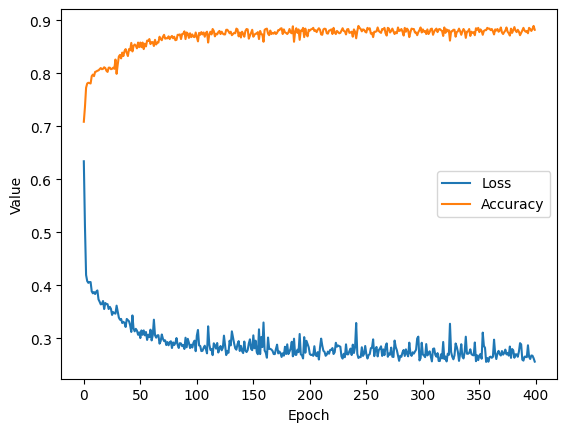

In [195]:
from tensorflow.keras.utils import to_categorical 
X=dataset[:,[1,3]]
Y=dataset[:,4]
Y_c=to_categorical(Y,2)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(2,)),  
    tf.keras.layers.Dense(2, activation='sigmoid')  
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.15),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


history = model.fit(X, Y_c, epochs=400, batch_size=128, verbose=1)

plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['accuracy'], label='Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.show()

## 6.5

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


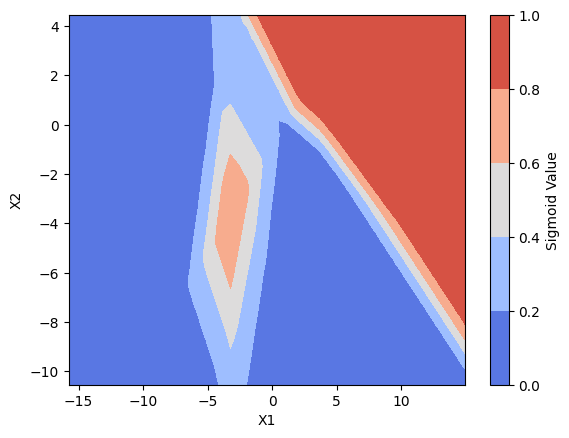

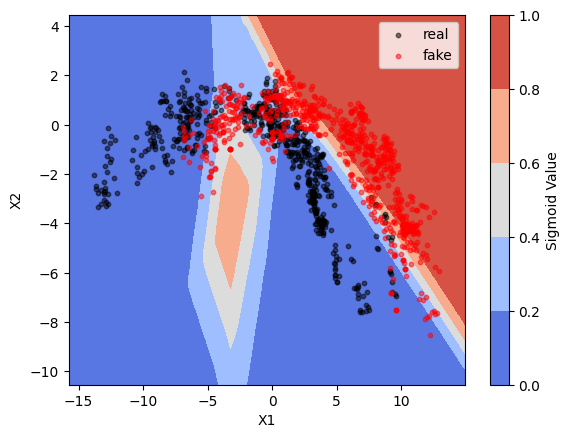

In [197]:
'''def sigmoid_2d(x, y):
    return 1 / (1 + np.exp(-(x + y)))'''
x1list = np.linspace(np.min(X[:,0])-2, np.max(X[:,0])+2, 50) # Define 50 points on the x1-axis
x2list = np.linspace(np.min(X[:,1])-2, np.max(X[:,1])+2, 50) # Define 50 points on the x2-axis
#model.predict(np.reshape(np.array([0.0,0.1]),(1,2)))

X1, X2 = np.meshgrid(x1list,x2list)
points = np.column_stack((X1.ravel(), X2.ravel()))
#print(points.shape)
ynew=model.predict(points).T[0]
#print(X1-X2)
Z = ynew.reshape(50,50)
#print(Z.shape)
contour = plt.contourf(X1, X2, Z, levels=5, cmap="coolwarm")
plt.colorbar(contour, label="Sigmoid Value")
plt.xlabel("X1")
plt.ylabel("X2")
#print(ynew.shape)
plt.show()
contour = plt.contourf(X1, X2, Z, levels=5, cmap="coolwarm")
plt.colorbar(contour, label="Sigmoid Value")
plt.xlabel("X1")
plt.ylabel("X2")
real,fake=real_or_fake(X,Y)
RT=np.array(real).T
FT=np.array(fake).T

#print(RT.shape)
plt.scatter(RT[0],RT[1],c = 'k',alpha=0.5,s=10)
plt.scatter(FT[0],FT[1],c = 'r',alpha=0.5,s=10)
plt.legend( labels=['real', 'fake'])

Now the over lap area has been counted to fake, instead of real in the previous.